<a href="https://colab.research.google.com/github/09StevenG/2022-ii-tutorial-git-repo-ejemplo/blob/main/Semana_03_dia_02_pandas_y_geopandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Continuación de Pandas y Geopandas
# preparar entorno
import pandas as pd
import geopandas as gpd

In [ ]:
#vamos a cargar un archivo
URL_INCOMPLETO = 'https://raw.githubusercontent.com/navilaufm/python-curso-gis/refs/heads/main/estaciones_region_incompleto.csv'
df = pd.read_csv(URL_INCOMPLETO)
df.head()

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124.0,2021-05-07
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2.0,2021-05-07
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2.0,2021-05-07
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32.0,2021-05-07
4,MUGM,Guantanamo Bay(MIL),Cuba,CU,Caribe,19.909,-75.206,NaN,2021-05-07


In [ ]:
#1 se carga primero el dato a df (pandas) ver ARRIBA
#2 se crea el geodataframe gdf indicándoles 2 cosas (los valores geográficos) y la el sistema de coordenadas
gdf = gpd.GeoDataFrame(df,  ###datos de la tabla
                       geometry=gpd.points_from_xy(df.longitud, df.latitud), #especificar las columnas que forman la geometría
                       crs="EPSG:4326") #obligatorio en qué están esa geometría

In [ ]:
gdf

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124.0,2021-05-07,POINT (-77.85 21.42)
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2.0,2021-05-07,POINT (-78.339 22.456)
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2.0,2021-05-07,POINT (-81.552 21.621)
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32.0,2021-05-07,POINT (-80.41 22.159)
4,MUGM,Guantanamo Bay(MIL),Cuba,CU,Caribe,19.909,-75.206,NaN,2021-05-07,POINT (-75.206 19.909)
...,...,...,...,...,...,...,...,...,...,...
494,SKPC,Puerto Carreno Arpt,Venezuela,VE,Sudamerica norte,6.184,-67.491,54.0,2021-07-15,POINT (-67.491 6.184)
495,SVCJ,San Carlos Arpt,Venezuela,VE,Sudamerica norte,9.648,-68.575,146.0,2021-05-07,POINT (-68.575 9.648)
496,SVSR,San Fernando Arpt,Venezuela,VE,Sudamerica norte,7.881,-67.443,45.0,2021-05-07,POINT (-67.443 7.881)
497,SVJM,San Juan los Morros,Venezuela,VE,Sudamerica norte,9.909,-67.377,446.0,2021-05-07,POINT (-67.377 9.909)


<Axes: >

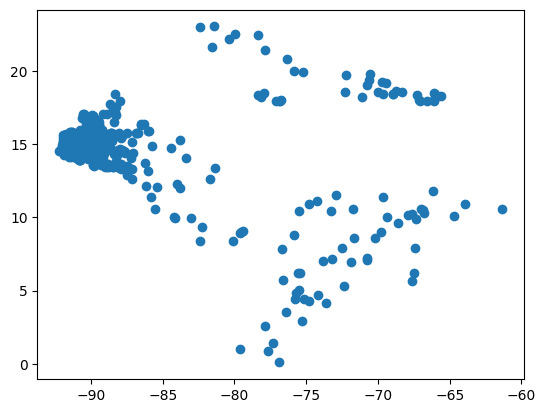

In [ ]:
gdf.plot()

In [ ]:
#obtner información de las coordenadas proyectadas
gdf.estimate_utm_crs()

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf.explore(
    column="pais", ##tiene que ser atributos de dataframe
    tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors',
    marker_kwds={"radius": 4},
    tooltip=["nombre", "pais", "altitud_msnm"]
)

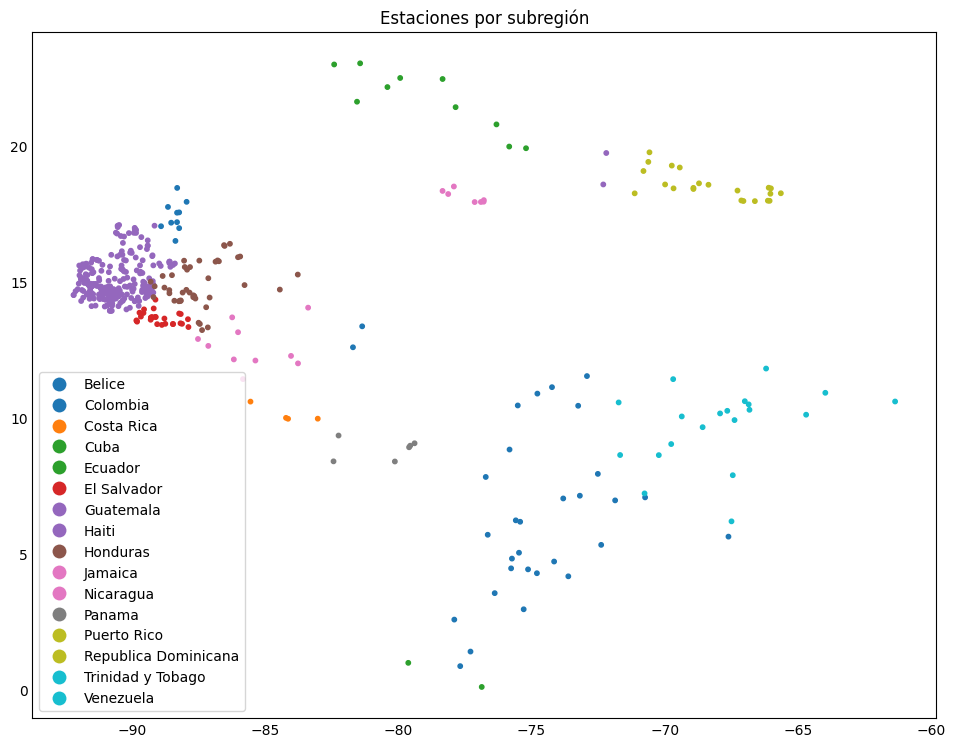

In [ ]:
###visualización estático
gdf.plot(column="pais", figsize=(11, 7), markersize=10, legend=True)
plt.title("Estaciones por subregión")
plt.show()

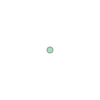

In [ ]:
gdf.geometry.iloc[0]

In [ ]:
print(type(gdf))
print(type(gdf.geometry))
print(type(gdf.geometry.iloc[0]))
print(gdf.crs)
print(gdf.shape)

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geoseries.GeoSeries'>
<class 'shapely.geometry.point.Point'>
EPSG:4326
(499, 10)


In [ ]:
#conocer que abarcan nuestros datos
gdf.total_bounds #nos da los extremos de una caja que abarca todo los datos W,S,E,N

array([-9.2195e+01,  9.2000e-02, -6.1348e+01,  2.3033e+01])

[-89.833  13.332 -87.882  14.34 ]


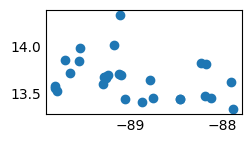

In [ ]:
#filtrar a un pais
gdf_SV = gdf[gdf["pais"] == "El Salvador"]
gdf_SV.plot()
print(gdf_SV.total_bounds)

In [ ]:
df.info() #nos indica si hay datos faltantes en cada columna, en este caso 499 en todos en altitud_msnm 309

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   codigo          499 non-null    object 
 1   nombre          499 non-null    object 
 2   pais            499 non-null    object 
 3   iso2            499 non-null    object 
 4   subregion       499 non-null    object 
 5   latitud         499 non-null    float64
 6   longitud        499 non-null    float64
 7   altitud_msnm    309 non-null    float64
 8   fecha_registro  499 non-null    object 
dtypes: float64(3), object(6)
memory usage: 35.2+ KB


In [ ]:
df.isna().sum() #cuantos vacíos hay en cada columna

,0
codigo,0
nombre,0
pais,0
iso2,0
subregion,0
latitud,0
longitud,0
altitud_msnm,190
fecha_registro,0


In [ ]:
print("Total de estaciones:", len(df))
print("Con altitud:", df["altitud_msnm"].notna().sum())
print("Sin altitud:", df["altitud_msnm"].isna().sum())

Total de estaciones: 499
Con altitud: 309
Sin altitud: 190


In [ ]:
resumen = gdf.groupby("pais")["altitud_msnm"].agg(total="size",con_dato_de_altitud="count") ##se agrega total y con_dato
resumen["sin_dato_de_altitud"] = resumen["total"] - resumen["con_dato_de_altitud"] #nueva columna sin_dato determina la diferencia
resumen["porcentaje"] = round(resumen["con_dato_de_altitud"] / resumen["total"] * 100,1) #nueva columna que estima el % de datos faltantes
#ordenar resumen de mayor a menor sin_dato
resumen = resumen.sort_values(by="sin_dato_de_altitud", ascending=False)
resumen

,total,con_dato_de_altitud,sin_dato_de_altitud,porcentaje
pais,,,,
Guatemala,303,185,118,61.1
Honduras,43,25,18,58.1
Colombia,31,19,12,61.3
El Salvador,29,18,11,62.1
Venezuela,19,13,6,68.4
Republica Dominicana,12,7,5,58.3
Belice,10,5,5,50.0
Puerto Rico,10,6,4,60.0
Nicaragua,10,7,3,70.0


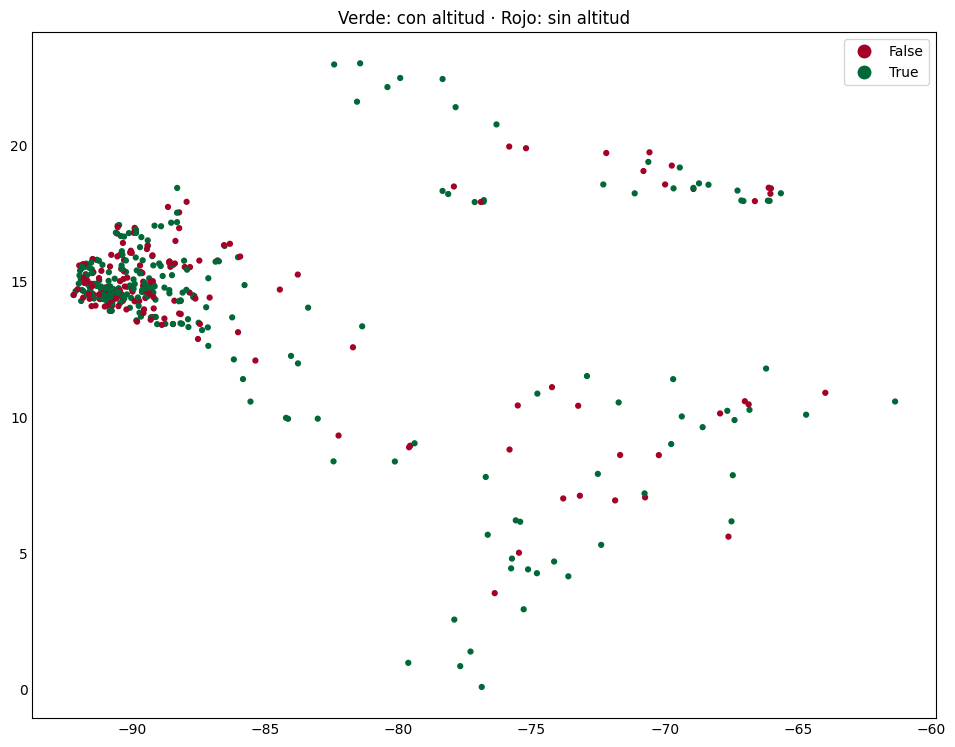

In [ ]:
#verlos en el mapa
gdf["tiene_altitud"] = gdf["altitud_msnm"].notna()

gdf.plot(column="tiene_altitud", figsize=(12, 7), markersize=12,
         legend=True, cmap="RdYlGn")
plt.title("Verde: con altitud · Rojo: sin altitud")
plt.show()

In [ ]:
#trabajamos solo con lo que tiene dato (otra opcion, clasificar lo que no tiene dato, o rellenear)
gdf_con_altitud = gdf[gdf["altitud_msnm"].notna()]
gdf_con_altitud

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry,tiene_altitud
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124.0,2021-05-07,POINT (-77.85 21.42),True
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2.0,2021-05-07,POINT (-78.339 22.456),True
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2.0,2021-05-07,POINT (-81.552 21.621),True
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32.0,2021-05-07,POINT (-80.41 22.159),True
5,MUHA,Havana/Marti Intl,Cuba,CU,Caribe,22.991,-82.410,58.0,2021-05-07,POINT (-82.41 22.991),True
...,...,...,...,...,...,...,...,...,...,...,...
492,SVBS,Maracay/Gomez Arpt,Venezuela,VE,Sudamerica norte,10.250,-67.649,431.0,2021-05-07,POINT (-67.649 10.25),True
494,SKPC,Puerto Carreno Arpt,Venezuela,VE,Sudamerica norte,6.184,-67.491,54.0,2021-07-15,POINT (-67.491 6.184),True
495,SVCJ,San Carlos Arpt,Venezuela,VE,Sudamerica norte,9.648,-68.575,146.0,2021-05-07,POINT (-68.575 9.648),True
496,SVSR,San Fernando Arpt,Venezuela,VE,Sudamerica norte,7.881,-67.443,45.0,2021-05-07,POINT (-67.443 7.881),True


309 estaciones con altitud
499 estaciones en la capa original (intacta)


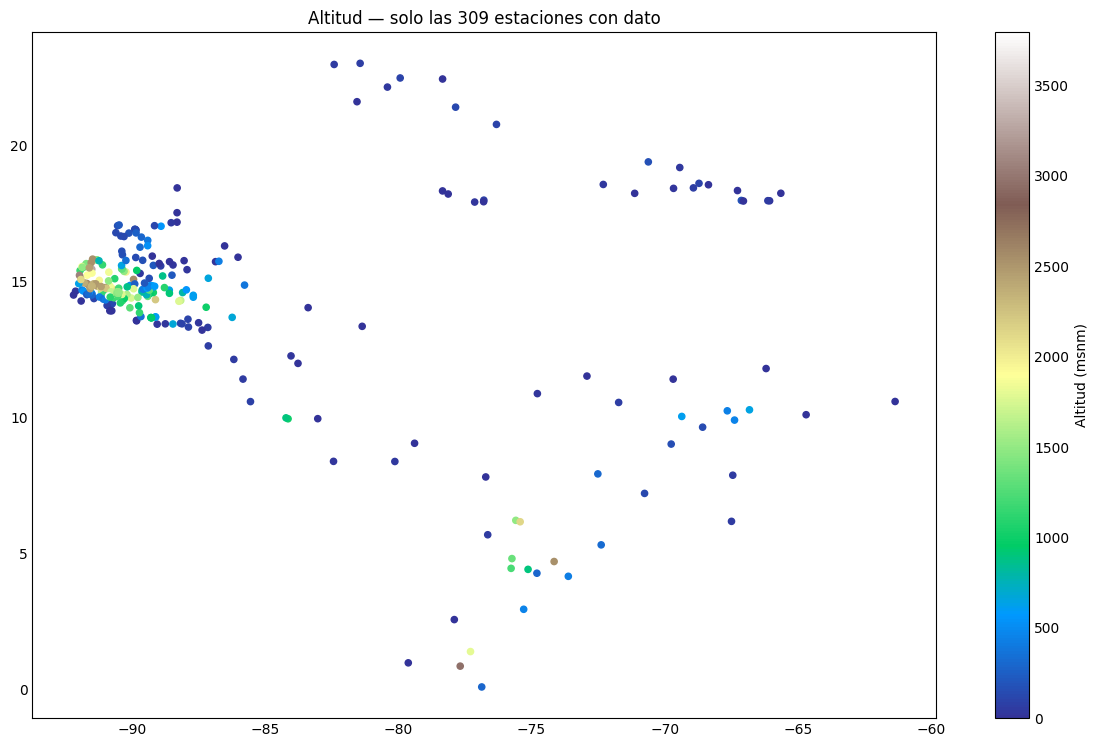

In [ ]:
### otra maneraborrando los que no son true o los que son na
con_alt = gdf.dropna(subset=["altitud_msnm"]) ##drop borra del gdf lo que cumple que es nulo pero el resultado lo asigna a un nuevo gdf

print(len(con_alt), "estaciones con altitud")
print(len(gdf), "estaciones en la capa original (intacta)")

con_alt.plot(column="altitud_msnm", cmap="terrain", figsize=(12, 7),
             markersize=20, legend=True,
             legend_kwds={"label": "Altitud (msnm)"})
plt.title(f"Altitud — solo las {len(con_alt)} estaciones con dato")
plt.show()

In [ ]:
con_alt

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry,tiene_altitud
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124.0,2021-05-07,POINT (-77.85 21.42),True
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2.0,2021-05-07,POINT (-78.339 22.456),True
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2.0,2021-05-07,POINT (-81.552 21.621),True
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32.0,2021-05-07,POINT (-80.41 22.159),True
5,MUHA,Havana/Marti Intl,Cuba,CU,Caribe,22.991,-82.410,58.0,2021-05-07,POINT (-82.41 22.991),True
...,...,...,...,...,...,...,...,...,...,...,...
492,SVBS,Maracay/Gomez Arpt,Venezuela,VE,Sudamerica norte,10.250,-67.649,431.0,2021-05-07,POINT (-67.649 10.25),True
494,SKPC,Puerto Carreno Arpt,Venezuela,VE,Sudamerica norte,6.184,-67.491,54.0,2021-07-15,POINT (-67.491 6.184),True
495,SVCJ,San Carlos Arpt,Venezuela,VE,Sudamerica norte,9.648,-68.575,146.0,2021-05-07,POINT (-68.575 9.648),True
496,SVSR,San Fernando Arpt,Venezuela,VE,Sudamerica norte,7.881,-67.443,45.0,2021-05-07,POINT (-67.443 7.881),True


In [ ]:
##sigue intacta la fuente ?
##COPIAR gdf
gdf_copia = gdf.copy() #para no perder gdf
gdf_copia.dropna(subset=["altitud_msnm"], inplace=True) #no asigné a un nuevo gdf
gdf_copia #acá perdemos la data original


,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry,tiene_altitud
0,MUCM,Camaguey/Agramonte A,Cuba,CU,Caribe,21.420,-77.850,124.0,2021-05-07,POINT (-77.85 21.42),True
1,MUCC,Cayo Coco/Rey Arpt,Cuba,CU,Caribe,22.456,-78.339,2.0,2021-05-07,POINT (-78.339 22.456),True
2,MUCL,Cayo Largo del Sur A,Cuba,CU,Caribe,21.621,-81.552,2.0,2021-05-07,POINT (-81.552 21.621),True
3,MUCF,Cienfuegos/Gonzales,Cuba,CU,Caribe,22.159,-80.410,32.0,2021-05-07,POINT (-80.41 22.159),True
5,MUHA,Havana/Marti Intl,Cuba,CU,Caribe,22.991,-82.410,58.0,2021-05-07,POINT (-82.41 22.991),True
...,...,...,...,...,...,...,...,...,...,...,...
492,SVBS,Maracay/Gomez Arpt,Venezuela,VE,Sudamerica norte,10.250,-67.649,431.0,2021-05-07,POINT (-67.649 10.25),True
494,SKPC,Puerto Carreno Arpt,Venezuela,VE,Sudamerica norte,6.184,-67.491,54.0,2021-07-15,POINT (-67.491 6.184),True
495,SVCJ,San Carlos Arpt,Venezuela,VE,Sudamerica norte,9.648,-68.575,146.0,2021-05-07,POINT (-68.575 9.648),True
496,SVSR,San Fernando Arpt,Venezuela,VE,Sudamerica norte,7.881,-67.443,45.0,2021-05-07,POINT (-67.443 7.881),True


In [ ]:
### vamos a revisar los datos pero con el archivo completo
URL_COMPLETO = "https://raw.githubusercontent.com/navilaufm/python-curso-gis/main/estaciones_region.csv"

df_full = pd.read_csv(URL_COMPLETO)

gdf_full = gpd.GeoDataFrame(
    df_full,
    geometry=gpd.points_from_xy(df_full["longitud"], df_full["latitud"]),
    crs="EPSG:4326"
)

print("Vacíos:", gdf_full["altitud_msnm"].isna().sum())
print(len(gdf_full), "estaciones, todas con altitud")

Vacíos: 0
499 estaciones, todas con altitud


In [ ]:
#por que es importante limpiar datos?
media_incompleta = con_alt["altitud_msnm"].mean()
media_completa = gdf_full["altitud_msnm"].mean()

print(f"Con el archivo incompleto: {media_incompleta:.1f} msnm")
print(f"Con el archivo completo:   {media_completa:.1f} msnm")
print(f"Diferencia: {media_incompleta - media_completa:.1f} m")

Con el archivo incompleto: 869.0 msnm
Con el archivo completo:   827.2 msnm
Diferencia: 41.8 m


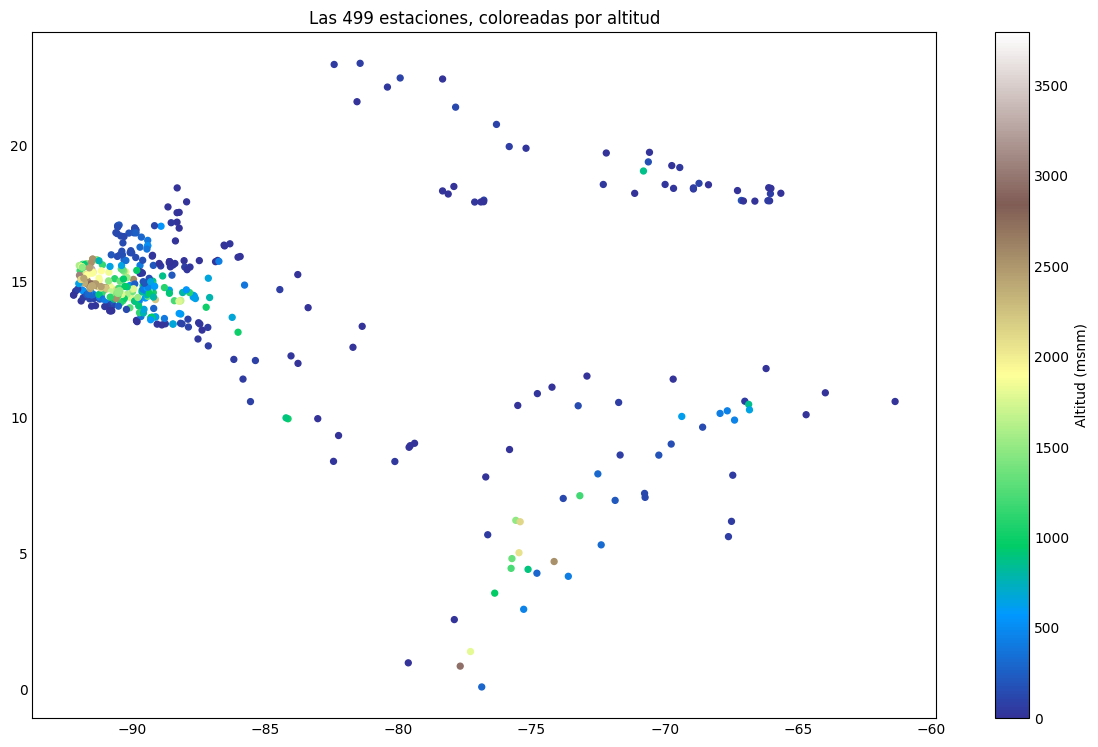

In [ ]:
#mapa completo
gdf_full.plot(column="altitud_msnm", cmap="terrain", figsize=(12, 7),
              markersize=18, legend=True,
              legend_kwds={"label": "Altitud (msnm)"})
plt.title("Las 499 estaciones, coloreadas por altitud")
plt.show()

In [ ]:
print("Altitud máxima:", gdf_full["altitud_msnm"].max(), "msnm")
print(gdf_full.loc[gdf_full["altitud_msnm"].idxmax(), ["nombre", "pais"]].to_dict())

Altitud máxima: 3794 msnm
{'nombre': 'Volcán de Fuego (EMI)', 'pais': 'Guatemala'}


In [ ]:
gt=gdf_full[gdf_full["pais"]=="Guatemala"]
gt.explore(tiles="https://tile.openstreetmap.de/{z}/{x}/{y}.png",
    attr='&copy; <a href="https://opentopomap.org">OpenTopoMap</a> contributors')

In [ ]:
utm_gt = gt.estimate_utm_crs()
print(utm_gt)

EPSG:32615


In [ ]:
#aplicamos solo al area de estudio (En este caso Guatemala)
gt_utm = gt.to_crs(utm_gt)

print("Antes:", gt.geometry.iloc[0]) #en grados decimales
print("Ahora:", gt_utm.geometry.iloc[0]) ##en metros

Antes: POINT (-91.51 14.86)
Ahora: POINT (660305.6729989406 1643376.1178786387)


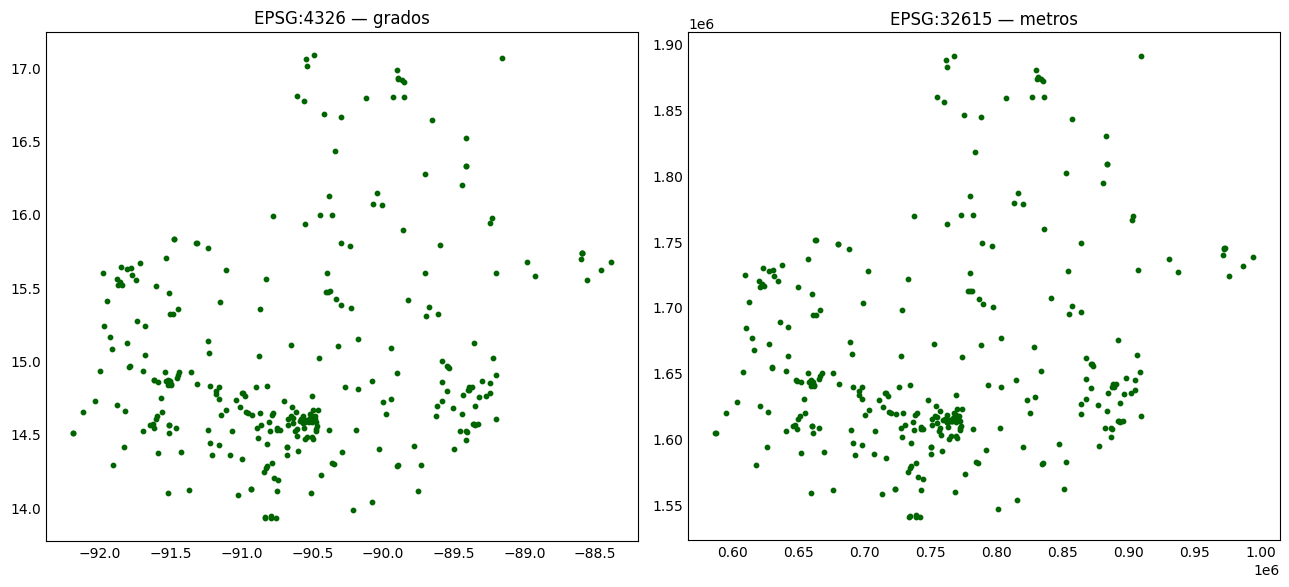

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

gt.plot(ax=ax1, markersize=10, color="darkgreen")
ax1.set_title("EPSG:4326 — grados")

gt_utm.plot(ax=ax2, markersize=10, color="darkgreen")
ax2.set_title(f"{utm_gt.to_string()} — metros")

plt.tight_layout()
plt.show()

In [ ]:
#medir distancia entre 2 puntos
a = gt_utm.geometry.iloc[0]
b = gt_utm.geometry.iloc[4]

print(gt_utm["nombre"].iloc[0], " a ", gt_utm["nombre"].iloc[4])
print(f"Distancia: {a.distance(b)/1000:.1f} km")

AAZ Xela  a  Aldea Agua Escondida, S.A. Palopó
Distancia: 48.4 km


In [ ]:
### las operaciones de distancia funcionan con grados decimales pero no son exactas
a = gt.geometry.iloc[0]
b = gt.geometry.iloc[4]

print(gt_utm["nombre"].iloc[0], " a ", gt_utm["nombre"].iloc[4])
print(f"Distancia: {a.distance(b)*111:.1f} km")

AAZ Xela  a  Aldea Agua Escondida, S.A. Palopó
Distancia: 49.6 km


In [ ]:
buffer_utm = gt_utm.geometry.iloc[[0]].buffer(10000)      # 10 000 metros

print(f"En UTM:  {buffer_utm.area.iloc[0]/1e6:.1f} km2")

En UTM:  313.7 km2


<Axes: >

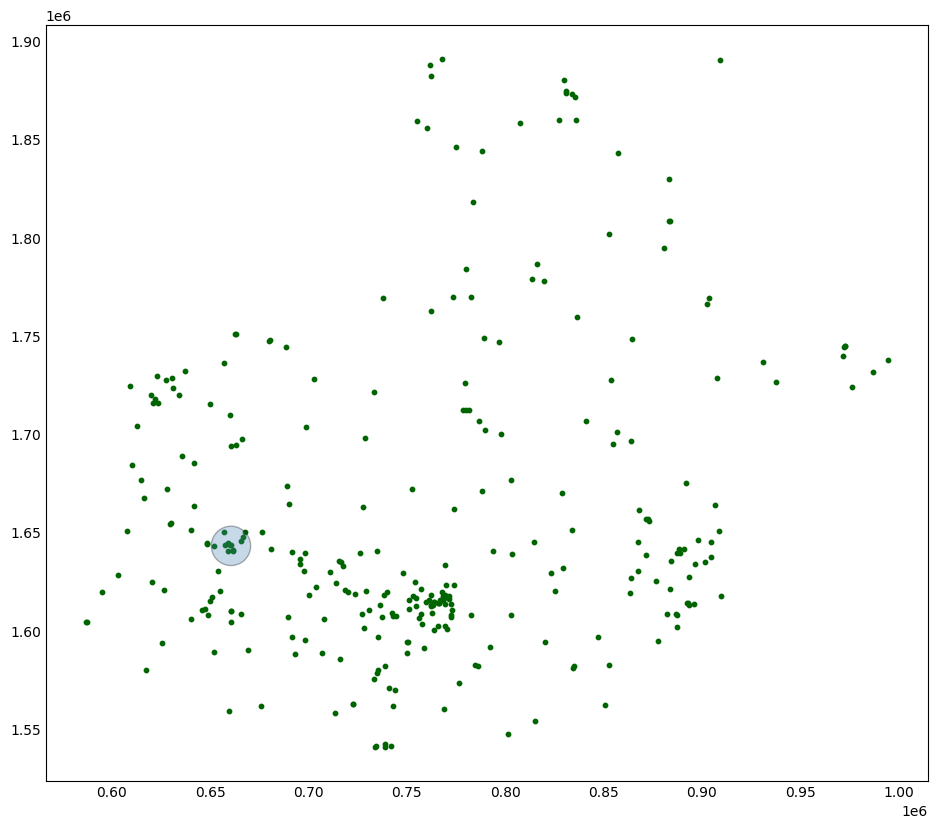

In [ ]:
#mostrar el buffer de la primera estación
fig, ax = plt.subplots(figsize=(9, 8))
gt_utm.plot(ax=ax, markersize=10, color="darkgreen")
buffer_utm.plot(ax=ax, alpha=0.3, color="steelblue", edgecolor="black")

In [ ]:
#un buffer en grados aunque es geograficamente posible, territorialmente no tiene sentido
buffer_grados = buffer_utm.to_crs("EPSG:4326")

print("En grados:", round(buffer_grados.area.iloc[0], 6), "«grados cuadrados»")

En grados: 0.026344 «grados cuadrados»


/tmp/ipykernel_6277/911111266.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print("En grados:", round(buffer_grados.area.iloc[0], 6), "«grados cuadrados»")


In [ ]:
#exportar estaciones de guatemala
gt.to_file("estaciones_guatemala.gpkg", layer="estaciones", driver="GPKG")

prueba = gpd.read_file("estaciones_guatemala.gpkg", layer="estaciones")
print(prueba.shape, prueba.crs)
prueba.head(2)

(303, 10) EPSG:4326


,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry
0,MGQZAAZ,AAZ Xela,Guatemala,GT,Centroamerica,14.86000,-91.51000,2372,2023-04-24,POINT (-91.51 14.86)
1,79291,ASECAJ,Guatemala,GT,Centroamerica,15.35833,-90.22693,1973,2023-08-31,POINT (-90.22693 15.35833)


In [ ]:
gt_utm

,codigo,nombre,pais,iso2,subregion,latitud,longitud,altitud_msnm,fecha_registro,geometry
85,MGQZAAZ,AAZ Xela,Guatemala,GT,Centroamerica,14.86000,-91.51000,2372,2023-04-24,POINT (660305.673 1643376.118)
86,79291,ASECAJ,Guatemala,GT,Centroamerica,15.35833,-90.22693,1973,2023-08-31,POINT (797724.086 1699868.817)
87,9b540e,AV Campat,Guatemala,GT,Centroamerica,15.38000,-90.30000,1495,2022-03-26,POINT (789844.014 1702168.619)
88,V-AGREX,Agrex,Guatemala,GT,Centroamerica,16.77000,-90.56000,136,2023-08-18,POINT (760102.19 1855710.254)
89,FF4778,"Aldea Agua Escondida, S.A. Palopó",Guatemala,GT,Centroamerica,14.66347,-91.10858,1933,2026-06-02,POINT (703688.781 1621956.123)
...,...,...,...,...,...,...,...,...,...,...
383,IGUATE6,Zona 15 Encinos,Guatemala,GT,Centroamerica,14.62000,-90.50000,1490,2024-09-15,POINT (769312.51 1617780.703)
384,688623,Zona 16,Guatemala,GT,Centroamerica,14.62000,-90.48000,1483,2022-06-14,POINT (771468.226 1617804.556)
385,IGUATE37,Zona 5 Vivibien,Guatemala,GT,Centroamerica,14.62000,-90.51000,1498,2024-09-15,POINT (768234.663 1617768.849)
386,59B438,chaucruz,Guatemala,GT,Centroamerica,14.82039,-91.16051,2458,2025-10-10,POINT (697952.776 1639273.501)


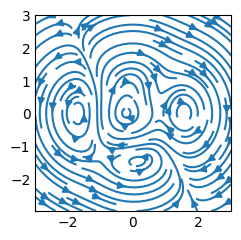

In [ ]:
###ejemplo de matplotlib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery-nogrid')

# make a stream function:
X, Y = np.meshgrid(np.linspace(-3, 3, 256), np.linspace(-3, 3, 256))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)
# make U and V out of the streamfunction:
V = np.diff(Z[1:, :], axis=1)
U = -np.diff(Z[:, 1:], axis=0)

# plot:
fig, ax = plt.subplots()

ax.streamplot(X[1:, 1:], Y[1:, 1:], U, V)

plt.show()